In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.shape

(145460, 23)

In [5]:
# to see the percentage of null values

per = df.isnull().mean()*100

print(per)


Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64


In [6]:
#dropping useless columns

df = df.drop(['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'Date'], axis=1)

In [7]:
df.info

<bound method DataFrame.info of        Location  MinTemp  MaxTemp  Rainfall WindGustDir  WindGustSpeed  \
0        Albury     13.4     22.9       0.6           W           44.0   
1        Albury      7.4     25.1       0.0         WNW           44.0   
2        Albury     12.9     25.7       0.0         WSW           46.0   
3        Albury      9.2     28.0       0.0          NE           24.0   
4        Albury     17.5     32.3       1.0           W           41.0   
...         ...      ...      ...       ...         ...            ...   
145455    Uluru      2.8     23.4       0.0           E           31.0   
145456    Uluru      3.6     25.3       0.0         NNW           22.0   
145457    Uluru      5.4     26.9       0.0           N           37.0   
145458    Uluru      7.8     27.0       0.0          SE           28.0   
145459    Uluru     14.9      NaN       0.0         NaN            NaN   

       WindDir9am WindDir3pm  WindSpeed9am  WindSpeed3pm  Humidity9am  \
0     

In [8]:
print(df.skew(numeric_only=True))



MinTemp          0.021188
MaxTemp          0.220839
Rainfall         9.836225
WindGustSpeed    0.874879
WindSpeed9am     0.777630
WindSpeed3pm     0.628215
Humidity9am     -0.483969
Humidity3pm      0.033614
Pressure9am     -0.095524
Pressure3pm     -0.045621
Temp9am          0.088540
Temp3pm          0.237960
dtype: float64


In [9]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    if abs(df[col].skew()) > 0.5:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Categorical columns → mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
df.isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [11]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

df = pd.get_dummies(df, columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], drop_first=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Columns: 107 entries, MinTemp to WindDir3pm_WSW
dtypes: bool(93), float64(12), int64(2)
memory usage: 28.4 MB


In [13]:
print(df.dtypes)
print(df.shape)

MinTemp           float64
MaxTemp           float64
Rainfall          float64
WindGustSpeed     float64
WindSpeed9am      float64
                   ...   
WindDir3pm_SSW       bool
WindDir3pm_SW        bool
WindDir3pm_W         bool
WindDir3pm_WNW       bool
WindDir3pm_WSW       bool
Length: 107, dtype: object
(145460, 107)


In [14]:
num_cols = df.select_dtypes(include='number').columns
skew = df[num_cols].skew().sort_values(ascending=False)
print(skew[skew.abs() > 0.5])

Rainfall         9.940909
RainTomorrow     1.357885
RainToday        1.357739
WindGustSpeed    0.923588
WindSpeed9am     0.786472
WindSpeed3pm     0.632461
dtype: float64


In [15]:
print("Before:", len(df))

cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After:", len(df))
print(df['RainTomorrow'].value_counts())

Before: 145460
After: 138153
RainTomorrow
0    109608
1     28545
Name: count, dtype: int64


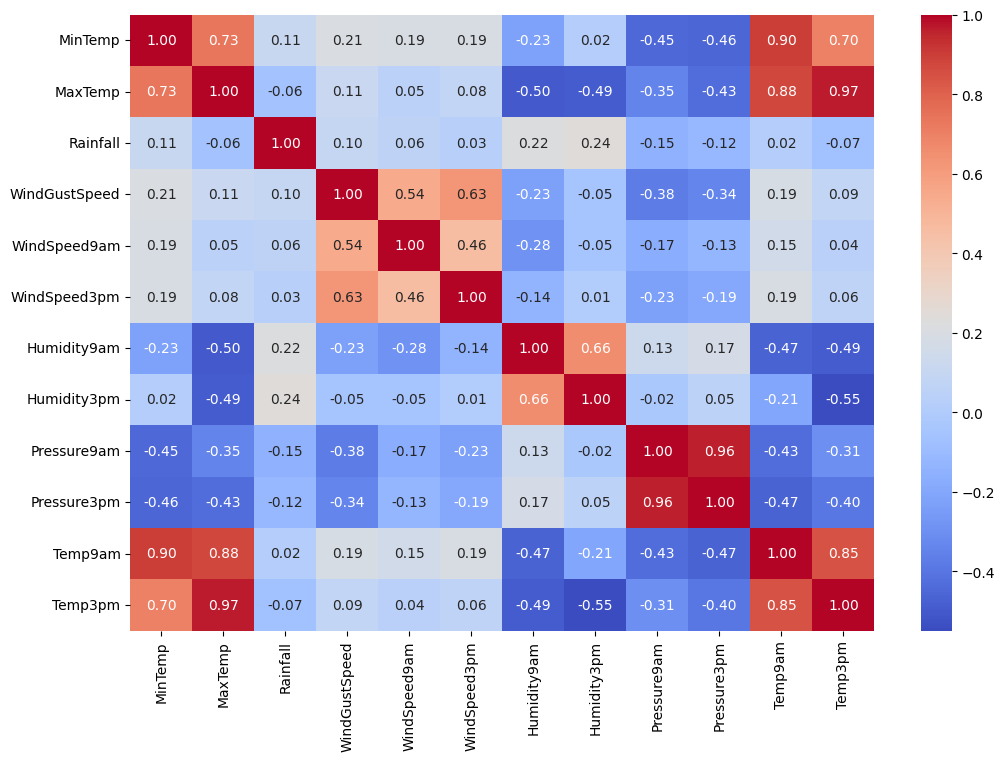

In [16]:
# step 1 - check correlation between numeric features only (pre-dummy cols)
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 
            'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 
            'Pressure3pm', 'Temp9am', 'Temp3pm']

corr = df[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# step 2 - drop columns where |r| > 0.85 with another feature


In [17]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col].abs() > 0.85)]
print("Columns to drop:", to_drop)

df = df.drop(columns=to_drop)

print("Shape after:", df.shape)

Columns to drop: ['Pressure3pm', 'Temp9am', 'Temp3pm']
Shape after: (138153, 104)


In [18]:
# define X and y
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# identify only continuous columns to scale
scale_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
              'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am']

# fit on train only (get mean and std from train)
train_mean = X_train[scale_cols].mean()
train_std = X_train[scale_cols].std()

# apply to both using train's mean and std
X_train[scale_cols] = (X_train[scale_cols] - train_mean) / train_std
X_test[scale_cols] = (X_test[scale_cols] - train_mean) / train_std

In [21]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(), y_test.value_counts())
print(X_train[scale_cols].mean().round(2))  # should be near 0
print(X_train[scale_cols].std().round(2))   # should be near 1
print(X_train.isnull().sum().sum())          # should be 0
print(X_test.isnull().sum().sum())  

(110522, 103) (27631, 103)
RainTomorrow
0    87686
1    22836
Name: count, dtype: int64 RainTomorrow
0    21922
1     5709
Name: count, dtype: int64
MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
WindGustSpeed   -0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am     -0.0
Humidity3pm     -0.0
Pressure9am     -0.0
dtype: float64
MinTemp          1.0
MaxTemp          1.0
Rainfall         1.0
WindGustSpeed    1.0
WindSpeed9am     1.0
WindSpeed3pm     1.0
Humidity9am      1.0
Humidity3pm      1.0
Pressure9am      1.0
dtype: float64
0
0


In [22]:
print(X_train.head())

         MinTemp   MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
124126  0.179073 -0.182265 -0.270722       0.253778      0.465328   
44457   0.648675  0.331279 -0.270722      -0.768458     -0.790101   
130709 -0.994933 -0.610218  0.031149       0.439639      1.093043   
125678 -1.135814 -0.710074 -0.270722      -0.489666     -0.036843   
37027  -1.824564 -0.795665 -0.270722      -1.326041     -1.166729   

        WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  RainToday  ...  \
124126      0.273397     0.368080    -0.265726    -0.051793          0  ...   
44457      -0.626397    -0.858814    -0.463233    -0.051793          0  ...   
130709      0.273397    -0.965501    -0.808870     0.893634          1  ...   
125678     -0.626397    -0.218696     0.228040    -0.051793          0  ...   
37027      -0.626397     1.488288    -0.364480     0.447827          0  ...   

        WindDir3pm_NNW  WindDir3pm_NW  WindDir3pm_S  WindDir3pm_SE  \
124126           False          False   

In [23]:
print(y_train)

124126    0
44457     0
130709    0
125678    0
37027     0
         ..
78579     0
126390    0
68233     0
15215     1
131297    1
Name: RainTomorrow, Length: 110522, dtype: int64


In [24]:
X_train_np = X_train.to_numpy(dtype=np.float64)
X_test_np  = X_test.to_numpy(dtype=np.float64)

y_train_np = y_train.to_numpy(dtype=np.float64).reshape(-1,1)
y_test_np  = y_test.to_numpy(dtype=np.float64).reshape(-1,1)

#converting all to numpy arrays

In [25]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [26]:
def initialize(X):
    m, n = X.shape
    w = np.zeros((n,1))
    b = 0.0
    return w, b

In [27]:
def forward(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

In [28]:
def compute_cost(y, y_hat):
    m = y.shape[0]
    
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    
    cost = -(1/m) * np.sum(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))
    return cost

In [29]:
def gradients(X, y, y_hat):
    m = X.shape[0]
    
    dw = (1/m) * np.dot(X.T, (y_hat - y))
    db = (1/m) * np.sum(y_hat - y)
    
    return dw, db

In [30]:
def train(X, y, lr=0.001, epochs=1000):
    w, b = initialize(X)
    
    for i in range(epochs):
        y_hat = forward(X, w, b)
        
        cost = compute_cost(y, y_hat)
        
        dw, db = gradients(X, y, y_hat)
        
        w -= lr * dw
        b -= lr * db
        
        if i % 100 == 0:
            print(f"Epoch {i}, Cost: {cost:.6f}")
    
    return w, b

In [31]:
def predict_proba(X, w, b):
    return forward(X, w, b)

In [88]:
def predict(X, w, b):
    probs = predict_proba(X, w, b)
    return (probs >= 0.33).astype(int)

In [57]:
w, b = train(X_train_np, y_train_np, lr=0.1, epochs=3000)

Epoch 0, Cost: 0.693147
Epoch 100, Cost: 0.390593
Epoch 200, Cost: 0.374789
Epoch 300, Cost: 0.370222
Epoch 400, Cost: 0.368046
Epoch 500, Cost: 0.366706
Epoch 600, Cost: 0.365749
Epoch 700, Cost: 0.365005
Epoch 800, Cost: 0.364396
Epoch 900, Cost: 0.363882
Epoch 1000, Cost: 0.363439
Epoch 1100, Cost: 0.363052
Epoch 1200, Cost: 0.362708
Epoch 1300, Cost: 0.362400
Epoch 1400, Cost: 0.362122
Epoch 1500, Cost: 0.361869
Epoch 1600, Cost: 0.361638
Epoch 1700, Cost: 0.361424
Epoch 1800, Cost: 0.361227
Epoch 1900, Cost: 0.361043
Epoch 2000, Cost: 0.360872
Epoch 2100, Cost: 0.360711
Epoch 2200, Cost: 0.360561
Epoch 2300, Cost: 0.360419
Epoch 2400, Cost: 0.360285
Epoch 2500, Cost: 0.360158
Epoch 2600, Cost: 0.360039
Epoch 2700, Cost: 0.359925
Epoch 2800, Cost: 0.359817
Epoch 2900, Cost: 0.359715


In [95]:

y_pred = predict(X_test_np, w, b)

In [96]:
accuracy = np.mean(y_pred == y_test_np)
print("Accuracy:", accuracy)

Accuracy: 0.832832687922985


In [97]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_test_np, y_pred)

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 3545
TN: 19467
FP: 2455
FN: 2164


In [98]:
precision = TP / (TP + FP) if (TP + FP) else 0
recall    = TP / (TP + FN) if (TP + FN) else 0
f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.5908333333333333
Recall: 0.6209493781748117
F1: 0.605517123580152


In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:",    recall_score(y_test_np, y_pred))
print("F1 weighted: ",        f1_score(y_test_np, y_pred, average='weighted'))
print("F! macro: ", f1_score(y_test_np, y_pred, average='macro'))
print("F1:",        f1_score(y_test_np, y_pred))

Precision: 0.5908333333333333
Recall: 0.6209493781748117
F1 weighted:  0.8343515001569015
F! macro:  0.7497312157978366
F1: 0.605517123580152
